<a href="https://colab.research.google.com/github/JosephAt10/PCVK_2026/blob/main/Week5_244107020242.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo
NAMA = 'Joseph Atem Deng Aruei'
NIM = '244107020242'
N = int(NIM[-3:])
PARAM = {
 'bins' : 2 ** ((N % 4) + 3),
 'clip' : round(1.0 + (N % 5) * 0.5, 1),
 'tile' : (N % 4) + 2,
 'L' : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
 print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])


NAMA : Joseph Atem Deng Aruei
NIM : 244107020242 | N = 242
bins   : 32
clip   : 2.0
tile   : 4
L      : 8
WAKTU : 2026-09-30 15:18:15 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 61d2fdc1c3b05565


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

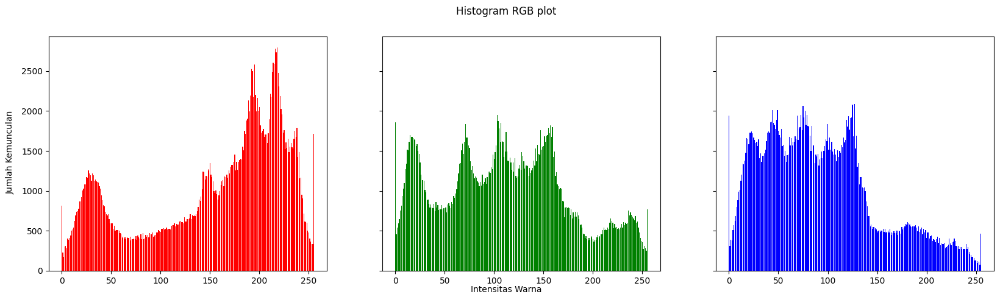

In [9]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK_2026/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
 for x in range(0,width) :
     red [img [y] [x] [0]] += 1
     green [img [y] [x] [1] ] += 1
     blue[img[y] [x] [2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig. suptitle('Histogram RGB plot')
fig. text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs [0]. bar(names, red, color='red')
axs [1] . bar(names, green, color='green')
axs [2] .bar(names, blue, color='blue')

<BarContainer object of 256 artists>

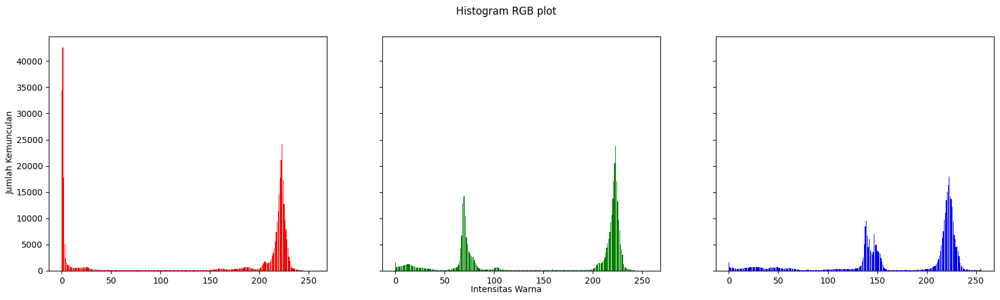

In [14]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK_2026/Images/244107020242/KTM1b.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
 for x in range(0,width) :
     red [img [y] [x] [0]] += 1
     green [img [y] [x] [1] ] += 1
     blue[img[y] [x] [2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig. suptitle('Histogram RGB plot')
fig. text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs [0]. bar(names, red, color='red')
axs [1] . bar(names, green, color='green')
axs [2] .bar(names, blue, color='blue')

In [15]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os

In [16]:
EXAMPLE = '/content/drive/MyDrive/PCVK_2026/Images'
BASE = '/content/drive/MyDrive/PCVK_2026/Images/244107020242'

def read_gray(file):
    img = cv.imread(file, cv.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError('Could not read image: ' + file)
    return img

def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h

In [17]:
def compare_histograms(file, image_name):
    gray = read_gray(file)

    h_manual = histogram_manual(gray)

    h_numpy, _ = np.histogram(
        gray.ravel(),
        bins=256,
        range=(0, 256)
    )
    h_cv = cv.calcHist([gray], [0], None, [256], [0, 256]).ravel()

    diff_manual_numpy = np.max(np.abs(h_manual - h_numpy))
    diff_manual_cv = np.max(np.abs(h_manual - h_cv))
    diff_numpy_cv = np.max(np.abs(h_numpy - h_cv))

    print(NIM + ' - ' + image_name)
    print('Maximum difference: manual vs NumPy =', diff_manual_numpy)
    print('Maximum difference: manual vs cv.calcHist =', diff_manual_cv)
    print('Maximum difference: NumPy vs cv.calcHist =', diff_numpy_cv)
    print('Pixel count check:', h_manual.sum(), '=', gray.size)
    print()

In [18]:
compare_histograms(os.path.join(EXAMPLE, 'lena.jpg'), 'lena.jpg')

244107020242 - lena.jpg
Maximum difference: manual vs NumPy = 0
Maximum difference: manual vs cv.calcHist = 0.0
Maximum difference: NumPy vs cv.calcHist = 0.0
Pixel count check: 262144 = 262144



In [19]:
compare_histograms(os.path.join(BASE, 'KTM1b.jpg'), 'KTM1b.jpg')

244107020242 - KTM1b.jpg
Maximum difference: manual vs NumPy = 0
Maximum difference: manual vs cv.calcHist = 0.0
Maximum difference: NumPy vs cv.calcHist = 0.0
Pixel count check: 362700 = 362700



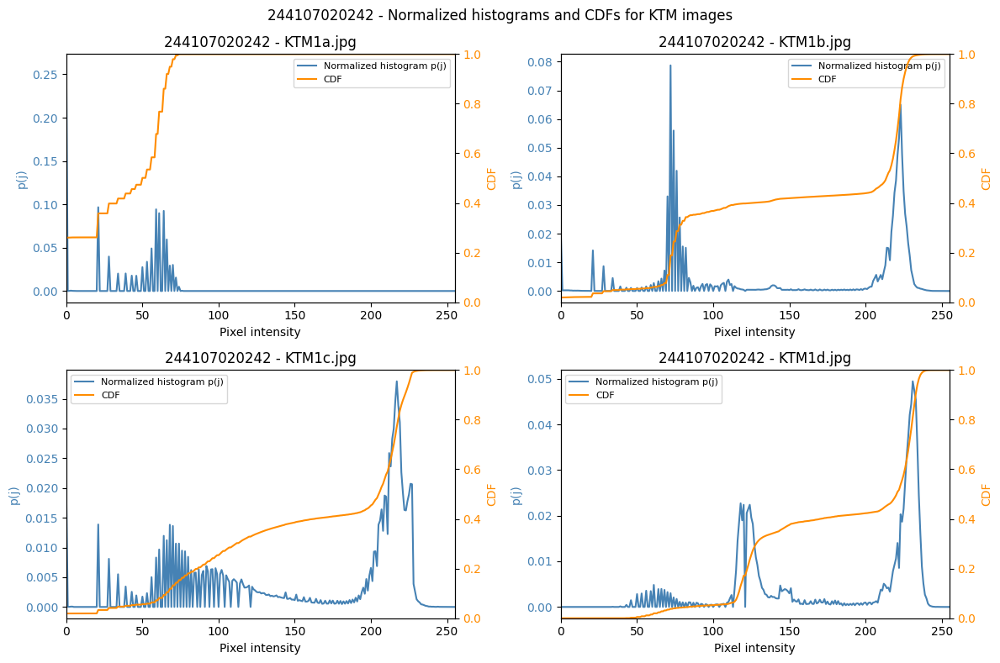

In [21]:
ktm_files = ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, filename in zip(axes, ktm_files):
    gray = read_gray(os.path.join(BASE, filename))

    h = histogram_manual(gray)
    p = h / gray.size
    cdf = np.cumsum(p)
    intensities = np.arange(256)

    # Normalized histogram p(j)
    ax.plot(intensities, p, color='steelblue', label='Normalized histogram p(j)')
    ax.set_xlabel('Pixel intensity')
    ax.set_ylabel('p(j)', color='steelblue')
    ax.tick_params(axis='y', labelcolor='steelblue')
    ax.set_xlim(0, 255)

    # CDF
    ax_cdf = ax.twinx()
    ax_cdf.plot(intensities, cdf, color='darkorange', label='CDF')
    ax_cdf.set_ylabel('CDF', color='darkorange')
    ax_cdf.tick_params(axis='y', labelcolor='darkorange')
    ax_cdf.set_ylim(0, 1)

    ax.set_title(NIM + ' - ' + filename)

    # One legend for both axes
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax_cdf.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=8)

fig.suptitle(NIM + ' - Normalized histograms and CDFs for KTM images')
fig.tight_layout()
plt.show()

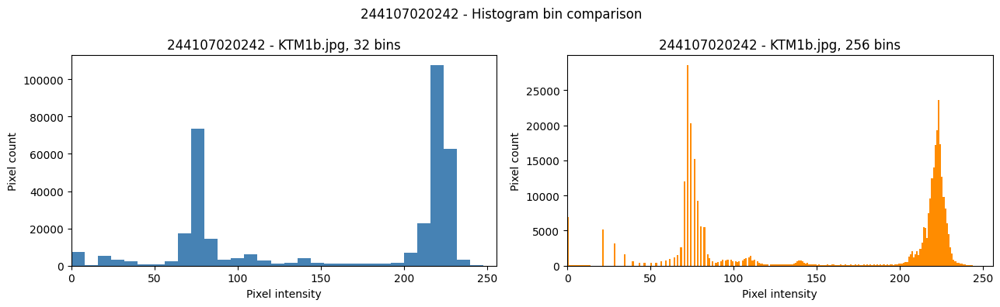

In [22]:
gray = read_gray(os.path.join(BASE, 'KTM1b.jpg'))

h_param, edges_param = np.histogram(
    gray.ravel(),
    bins=PARAM['bins'],
    range=(0, 256)
)

h_256, edges_256 = np.histogram(
    gray.ravel(),
    bins=256,
    range=(0, 256)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: PARAM['bins']
centers_param = (edges_param[:-1] + edges_param[1:]) / 2
width_param = edges_param[1] - edges_param[0]
axes[0].bar(centers_param, h_param, width=width_param, color='steelblue')
axes[0].set_title(NIM + ' - KTM1b.jpg, ' + str(PARAM['bins']) + ' bins')
axes[0].set_xlabel('Pixel intensity')
axes[0].set_ylabel('Pixel count')
axes[0].set_xlim(0, 256)

# Right: 256 bins
centers_256 = (edges_256[:-1] + edges_256[1:]) / 2
axes[1].bar(centers_256, h_256, width=1, color='darkorange')
axes[1].set_title(NIM + ' - KTM1b.jpg, 256 bins')
axes[1].set_xlabel('Pixel intensity')
axes[1].set_ylabel('Pixel count')
axes[1].set_xlim(0, 256)

fig.suptitle(NIM + ' - Histogram bin comparison')
fig.tight_layout()
plt.show()

In [30]:
def read_color(file):
    bgr = cv.imread(file, cv.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError('Could not read image: ' + file)
    return bgr


def manual_equalize_color(bgr):
    equalized = np.empty_like(bgr)
    hist_before = []
    hist_after = []

    # OpenCV stores color channels as B, G, R
    for channel_index in range(3):
        channel = bgr[:, :, channel_index]

        h = histogram_manual(channel)

        cdf = np.cumsum(h) / channel.size

        transform = np.round(255 * cdf).astype(np.uint8)

        equalized[:, :, channel_index] = transform[channel]

        hist_before.append(h)
        hist_after.append(histogram_manual(equalized[:, :, channel_index]))

    return equalized, hist_before, hist_after

def show_color_equalization(file, image_name):
    original = read_color(file)
    equalized, hist_before, hist_after = manual_equalize_color(original)

    fig = plt.figure(figsize=(14, 8))
    grid = fig.add_gridspec(2, 6, height_ratios=[1.2, 1])

    # Display original and equalized images in color
    ax_original = fig.add_subplot(grid[0, :3])
    ax_original.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
    ax_original.set_title(NIM + ' - ' + image_name + ' original')
    ax_original.axis('off')

    ax_equalized = fig.add_subplot(grid[0, 3:])
    ax_equalized.imshow(cv.cvtColor(equalized, cv.COLOR_BGR2RGB))
    ax_equalized.set_title(NIM + ' - ' + image_name + ' equalized')
    ax_equalized.axis('off')

    # Show before-and-after histograms for each channel
    channel_names = ['Blue', 'Green', 'Red']
    channel_colors = ['blue', 'green', 'red']

    for i, (name, color) in enumerate(zip(channel_names, channel_colors)):
        ax = fig.add_subplot(grid[1, i * 2:(i + 1) * 2])
        ax.plot(hist_before[i], color=color, linestyle='--', label='Before')
        ax.plot(hist_after[i], color=color, label='After')
        ax.set_title(NIM + ' - ' + name + ' histogram')
        ax.set_xlabel('Pixel intensity')
        ax.set_ylabel('Pixel count')
        ax.set_xlim(0, 255)
        ax.legend()

    fig.suptitle(NIM + ' - Manual RGB histogram equalization: ' + image_name)
    fig.tight_layout()
    plt.show()

    return equalized

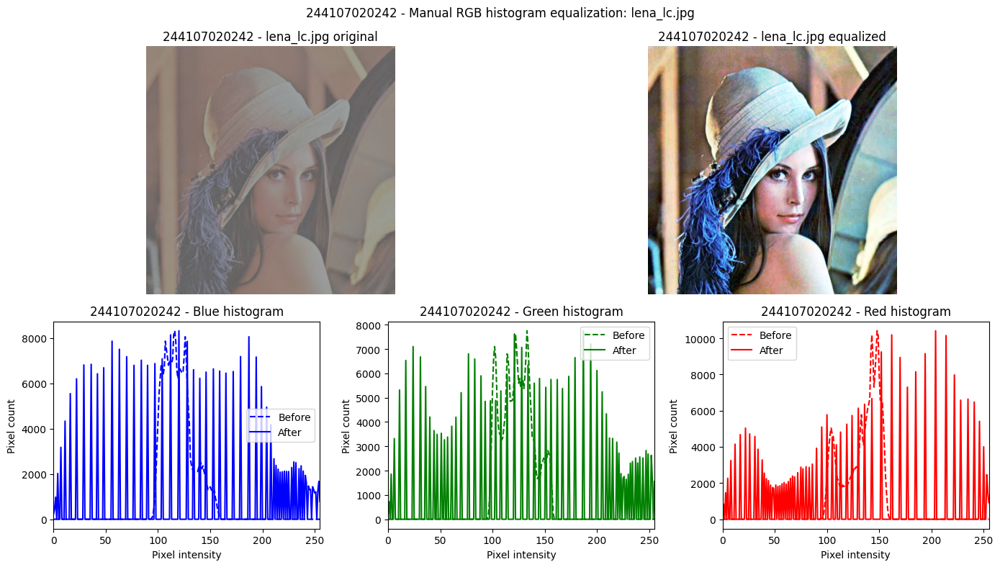

In [31]:
# Stage 1: check the sample against the module example
lena_equalized = show_color_equalization(
    os.path.join(EXAMPLE, 'lena_lc.jpg'),
    'lena_lc.jpg'
)

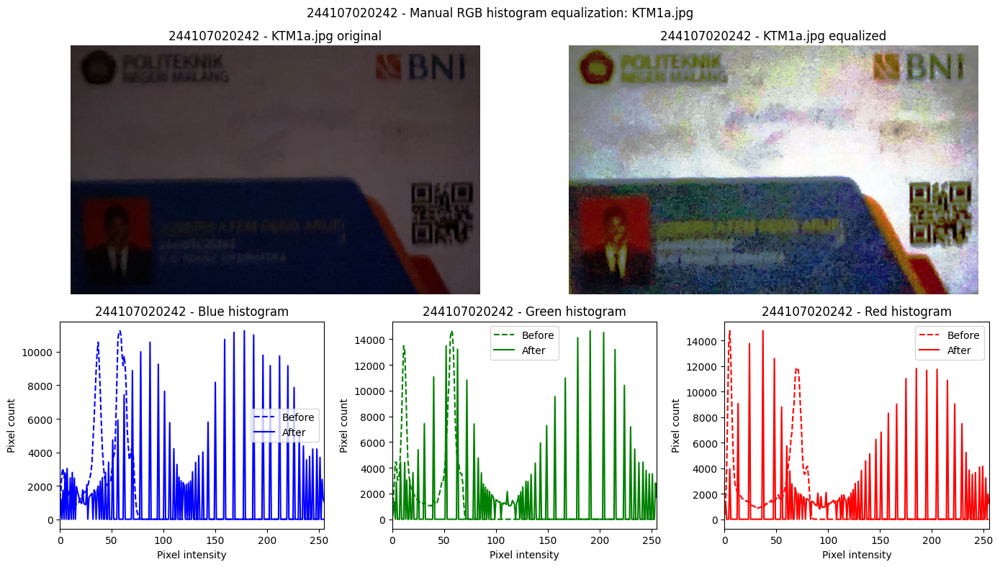

In [32]:
# Stage 2: repeat with your KTM photo
ktm_equalized = show_color_equalization(
    os.path.join(BASE, 'KTM1a.jpg'),
    'KTM1a.jpg'
)

In [35]:
def compare_manual_cv2_color(file, image_name):
    original = read_color(file)

    manual, _, _ = manual_equalize_color(original)

    b, g, r = cv.split(original)
    b_equalized = cv.equalizeHist(b)
    g_equalized = cv.equalizeHist(g)
    r_equalized = cv.equalizeHist(r)
    cv_result = cv.merge([b_equalized, g_equalized, r_equalized])

    difference = np.abs(
        manual.astype(np.int16) - cv_result.astype(np.int16)
    )

    print(NIM + ' - ' + image_name)
    print('Maximum difference, all channels:', int(difference.max()))

    for i, channel_name in enumerate(['Blue', 'Green', 'Red']):
        print(
            'Maximum difference, ' + channel_name + ':',
            int(difference[:, :, i].max())
        )

    # Display original and both equalized results
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    images = [
        (original, 'Original'),
        (manual, 'Manual equalization'),
        (cv_result, 'cv.equalizeHist')
    ]

    for ax, (image, label) in zip(axes[0], images):
        ax.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
        ax.set_title(NIM + ' - ' + image_name + ' - ' + label)
        ax.axis('off')

    # Compare histograms of the equalized images
    channel_names = ['Blue', 'Green', 'Red']
    channel_colors = ['blue', 'green', 'red']

    for i, (channel_name, color) in enumerate(
        zip(channel_names, channel_colors)
    ):
        h_manual = histogram_manual(manual[:, :, i])
        h_cv = histogram_manual(cv_result[:, :, i])

        axes[1, i].plot(h_manual, color=color, label='Manual')
        axes[1, i].plot(
            h_cv, color='black', linestyle='--', label='cv.equalizeHist'
        )
        axes[1, i].set_title(NIM + ' - ' + channel_name + ' histogram')
        axes[1, i].set_xlabel('Pixel intensity')
        axes[1, i].set_ylabel('Pixel count')
        axes[1, i].set_xlim(0, 255)
        axes[1, i].legend()

    fig.suptitle(NIM + ' - Manual and OpenCV equalization: ' + image_name)
    fig.tight_layout()
    plt.show()

    return cv_result

244107020242 - lena_lc.jpg
Maximum difference, all channels: 0
Maximum difference, Blue: 0
Maximum difference, Green: 0
Maximum difference, Red: 0


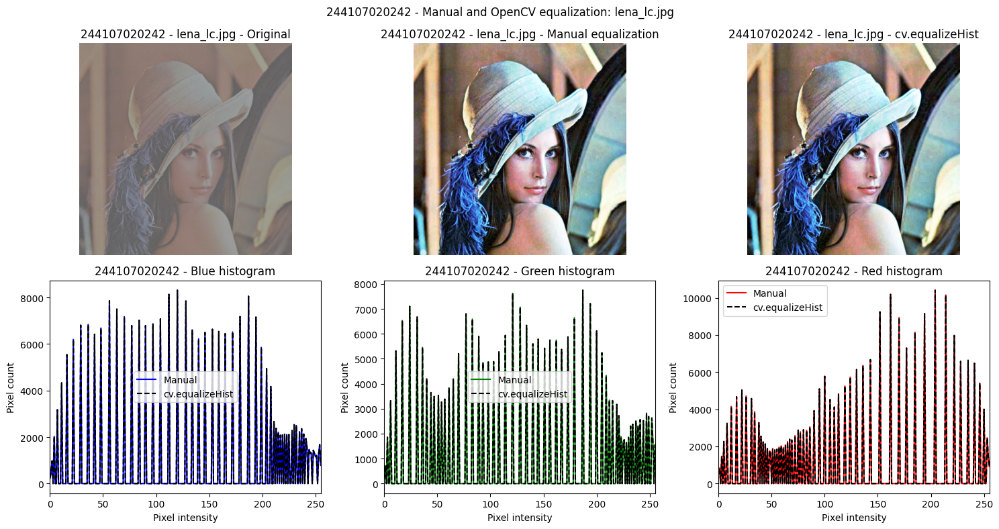

In [37]:
lena_cv_equalized = compare_manual_cv2_color(
    os.path.join(EXAMPLE, 'lena_lc.jpg'),
    'lena_lc.jpg'
)

244107020242 - KTM1a.jpg
Maximum difference, all channels: 2
Maximum difference, Blue: 2
Maximum difference, Green: 1
Maximum difference, Red: 1


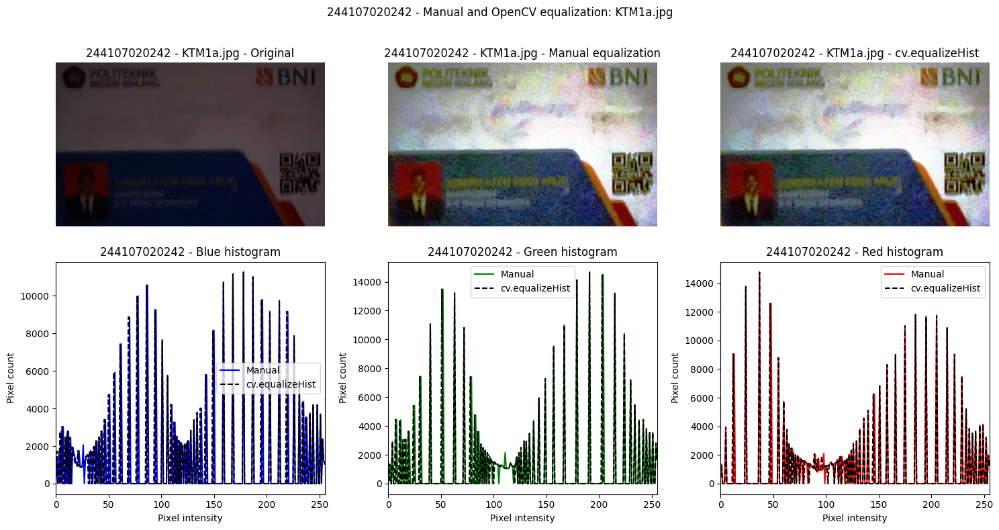

In [38]:
ktm_cv_equalized = compare_manual_cv2_color(
    os.path.join(BASE, 'KTM1a.jpg'),
    'KTM1a.jpg'
)

In [40]:
import cv2 as cv, numpy as np, matplotlib.pyplot as plt
berkas = EXAMPLE + '/lena.jpg' # tahap 1; tahap 2 ganti: BASE + '/KTM1d.jpg'
bgr = cv.imread(berkas)
# cara 1: tiap kanal diekualisasi sendiri-sendiri
kanal = list(cv.split(bgr))
for i in range(3):
 kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

In [47]:
import cv2 as cv, numpy as np, matplotlib.pyplot as plt
berkas = BASE + '/KTM1d.jpg' # tahap 1; tahap 2 ganti: BASE + '/KTM1d.jpg'
bgr = cv.imread(berkas)
# cara 1: tiap kanal diekualisasi sendiri-sendiri
kanal = list(cv.split(bgr))
for i in range(3):
 kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

In [48]:
def show_rgb_equalization(file, image_name):
    bgr = cv.imread(file)
    if bgr is None:
        raise FileNotFoundError('Could not read image: ' + file)

    channels = list(cv.split(bgr))
    for i in range(3):
        channels[i] = cv.equalizeHist(channels[i])
    he_rgb = cv.merge(channels)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
    axes[0].set_title(NIM + ' - ' + image_name + ' original')
    axes[0].axis('off')

    axes[1].imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB))
    axes[1].set_title(NIM + ' - ' + image_name + ' equalized')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

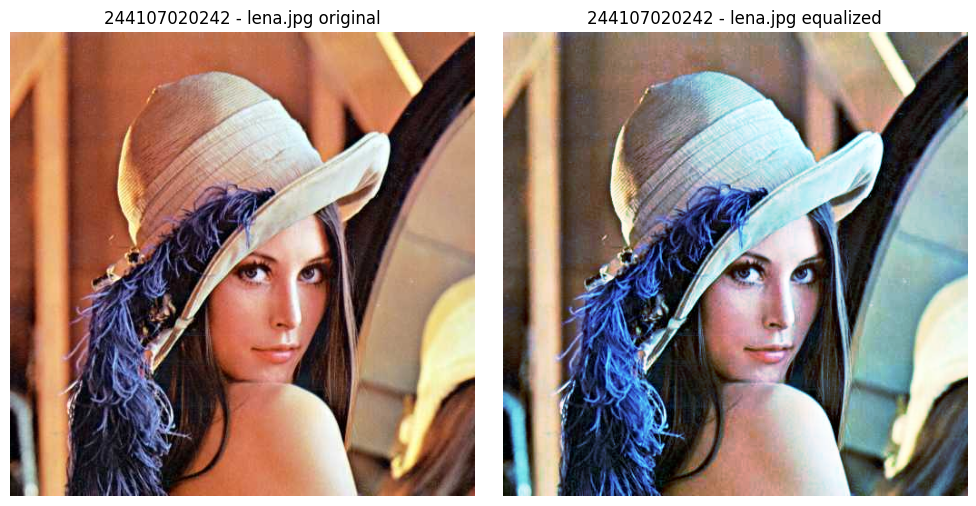

In [49]:
show_rgb_equalization(os.path.join(EXAMPLE, 'lena.jpg'), 'lena.jpg')

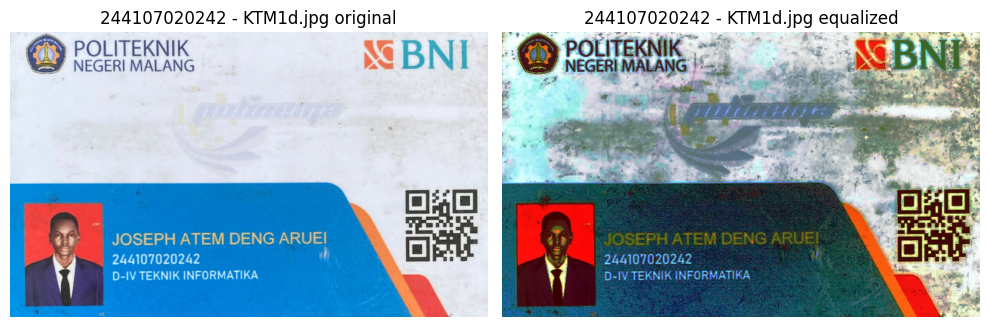

In [50]:
show_rgb_equalization(os.path.join(BASE, 'KTM1d.jpg'), 'KTM1d.jpg')

In [51]:
# cara 2: hanya kanal terang yang diekualisasi
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)
# varian setara pada ruang warna lain
hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)
lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

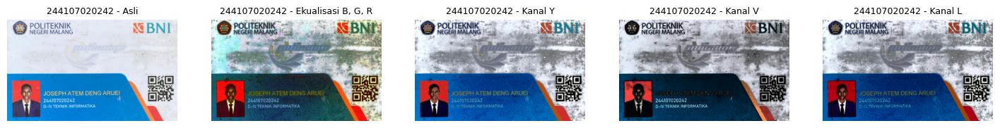

In [52]:
judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]
plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
 plt.subplot(1, 5, i)
 plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
 plt.title(NIM + ' - ' + t, fontsize=9)
 plt.axis('off')
plt.show()

In [55]:
def geser_hue(asli, hasil):
 h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
 h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
 d = np.abs(h1 - h2)
 d = np.minimum(d, 180 - d) # Hue melingkar 0-179
 return d.mean()
print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
 print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2,
 cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            175.9
Ekualisasi B, G, R                44.65            127.7
Kanal Y                            3.91            134.1
Kanal V                            2.57            111.8
Kanal L                            6.10            123.6


244107020242 - Regular Y equalization | Hue shift: 3.91 degrees | Average brightness: 134.1
244107020242 - CLAHE on Y | Hue shift: 1.38 degrees | Average brightness: 168.0


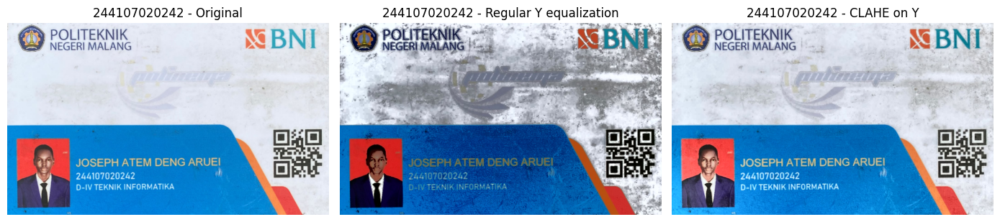

In [56]:
def hue_shift_degrees(original, result):
    h1 = cv.cvtColor(original, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(result, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)

    delta = np.abs(h1 - h2)
    delta = np.minimum(delta, 180 - delta)  # Hue is circular: 0–179
    return delta.mean() * 2  # Convert OpenCV Hue units to degrees


def average_brightness(image):
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    return gray.mean()


bgr = cv.imread(os.path.join(BASE, 'KTM1d.jpg'))
if bgr is None:
    raise FileNotFoundError('Could not read KTM1d.jpg from: ' + BASE)

# Split Y (brightness), Cr, and Cb (color information)
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)

# Regular equalization of Y
he_y = cv.cvtColor(
    cv.merge([cv.equalizeHist(y), cr, cb]),
    cv.COLOR_YCrCb2BGR
)

# CLAHE on Y, using your NIM-derived parameters
clahe = cv.createCLAHE(
    clipLimit=PARAM['clip'],
    tileGridSize=(PARAM['tile'], PARAM['tile'])
)
y_clahe = clahe.apply(y)

clahe_y = cv.cvtColor(
    cv.merge([y_clahe, cr, cb]),
    cv.COLOR_YCrCb2BGR
)

for label, result in [('Regular Y equalization', he_y), ('CLAHE on Y', clahe_y)]:
    print(
        NIM, '-', label,
        '| Hue shift:', round(hue_shift_degrees(bgr, result), 2), 'degrees',
        '| Average brightness:', round(average_brightness(result), 1)
    )

# Display the comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, image, label in zip(
    axes,
    [bgr, he_y, clahe_y],
    ['Original', 'Regular Y equalization', 'CLAHE on Y']
):
    ax.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
    ax.set_title(NIM + ' - ' + label)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [57]:
import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

EXAMPLE = '/content/drive/MyDrive/PCVK_2026/Images'
BASE = os.path.join(EXAMPLE, NIM)

def read_gray(file):
    image = cv.imread(file, cv.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError('Could not read image: ' + file)
    return image

def read_color(file):
    image = cv.imread(file, cv.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError('Could not read image: ' + file)
    return image

# Manual histogram and equalization, following the jobsheet flowchart
def histogram_manual(gray):
    h = np.zeros(256, dtype=np.int64)
    for y in range(gray.shape[0]):
        for x in range(gray.shape[1]):
            h[gray[y, x]] += 1
    return h

def manual_equalize_gray(gray):
    h = histogram_manual(gray)
    cdf = np.cumsum(h) / gray.size
    transform = np.round(255 * cdf).astype(np.uint8)
    return transform[gray]

def display_images(items, title, figsize=None):
    if figsize is None:
        figsize = (5 * len(items), 5)

    fig, axes = plt.subplots(1, len(items), figsize=figsize)
    if len(items) == 1:
        axes = [axes]

    for ax, (image, label) in zip(axes, items):
        if image.ndim == 2:
            ax.imshow(image, cmap='gray', vmin=0, vmax=255)
        else:
            ax.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
        ax.set_title(NIM + ' - ' + label)
        ax.axis('off')

    fig.suptitle(NIM + ' - ' + title)
    fig.tight_layout()
    plt.show()

244107020242 - PSNR, manual equalization: 7.2 dB
244107020242 - PSNR, cv.equalizeHist: 9.07 dB


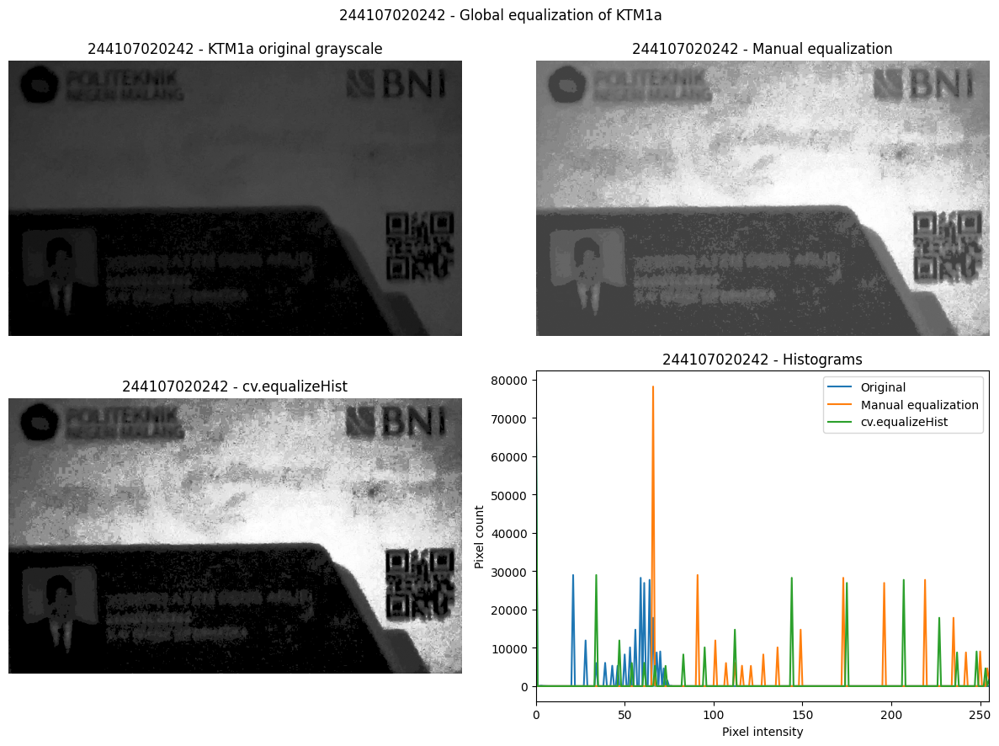

In [58]:
file = os.path.join(BASE, 'KTM1a.jpg')
ktm_gray = read_gray(file)

manual_equalized = manual_equalize_gray(ktm_gray)
cv_equalized = cv.equalizeHist(ktm_gray)

psnr_manual = cv.PSNR(ktm_gray, manual_equalized)
psnr_cv = cv.PSNR(ktm_gray, cv_equalized)

print(NIM, '- PSNR, manual equalization:', round(psnr_manual, 2), 'dB')
print(NIM, '- PSNR, cv.equalizeHist:', round(psnr_cv, 2), 'dB')

hist_original = histogram_manual(ktm_gray)
hist_manual = histogram_manual(manual_equalized)
hist_cv = histogram_manual(cv_equalized)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].imshow(ktm_gray, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title(NIM + ' - KTM1a original grayscale')
axes[0, 0].axis('off')

axes[0, 1].imshow(manual_equalized, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title(NIM + ' - Manual equalization')
axes[0, 1].axis('off')

axes[1, 0].imshow(cv_equalized, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title(NIM + ' - cv.equalizeHist')
axes[1, 0].axis('off')

axes[1, 1].plot(hist_original, label='Original')
axes[1, 1].plot(hist_manual, label='Manual equalization')
axes[1, 1].plot(hist_cv, label='cv.equalizeHist')
axes[1, 1].set_title(NIM + ' - Histograms')
axes[1, 1].set_xlabel('Pixel intensity')
axes[1, 1].set_ylabel('Pixel count')
axes[1, 1].set_xlim(0, 255)
axes[1, 1].legend()

fig.suptitle(NIM + ' - Global equalization of KTM1a')
fig.tight_layout()
plt.show()

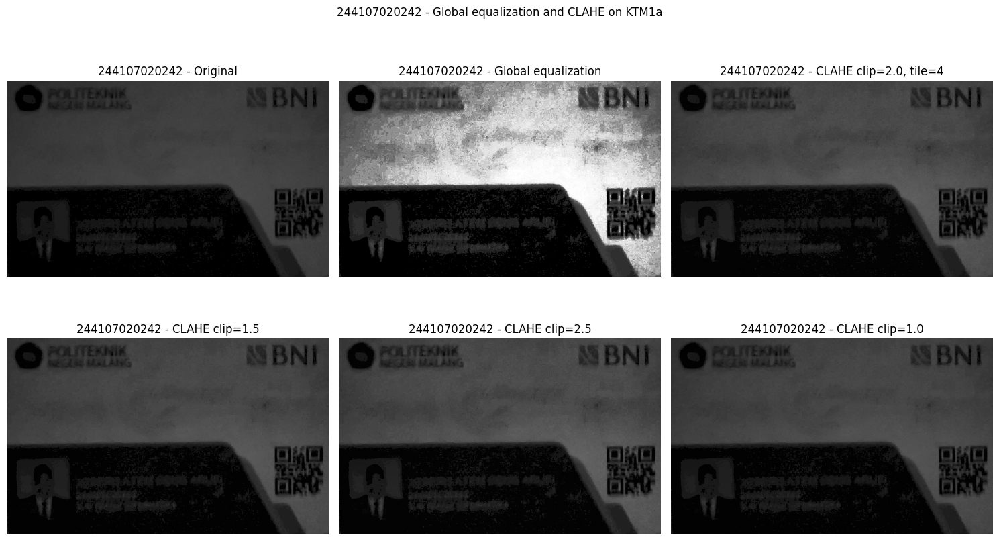

In [59]:
file = os.path.join(BASE, 'KTM1a.jpg')
ktm_gray = read_gray(file)

global_equalized = cv.equalizeHist(ktm_gray)

clip_values = np.arange(1.0, 3.01, 0.5)
other_clip_values = sorted(
    [round(float(value), 1)
     for value in clip_values
     if round(float(value), 1) != round(float(PARAM['clip']), 1)],
    key=lambda value: abs(value - PARAM['clip'])
)[:3]

results = [
    (ktm_gray, 'Original'),
    (global_equalized, 'Global equalization')
]

# Assigned CLAHE parameters
clahe_assigned = cv.createCLAHE(
    clipLimit=PARAM['clip'],
    tileGridSize=(PARAM['tile'], PARAM['tile'])
)
assigned_result = clahe_assigned.apply(ktm_gray)
results.append((
    assigned_result,
    'CLAHE clip=' + str(PARAM['clip']) +
    ', tile=' + str(PARAM['tile'])
))

# Three other clipLimit values
for clip_value in other_clip_values:
    clahe = cv.createCLAHE(
        clipLimit=clip_value,
        tileGridSize=(PARAM['tile'], PARAM['tile'])
    )
    result = clahe.apply(ktm_gray)
    results.append((result, 'CLAHE clip=' + str(clip_value)))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (image, label) in zip(axes.ravel(), results):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(NIM + ' - ' + label)
    ax.axis('off')

fig.suptitle(NIM + ' - Global equalization and CLAHE on KTM1a')
fig.tight_layout()
plt.show()

In [61]:
def floyd_steinberg_channel(source, L):
    if L < 2:
        raise ValueError('L must be at least 2')

    image = source.astype(np.float32).copy()
    height, width = image.shape
    step = 255.0 / (L - 1)

    def add_error(y, x, amount):
        image[y, x] = np.clip(image[y, x] + amount, 0, 255)

    for y in range(height):
        for x in range(width):
            old_value = image[y, x]
            new_value = np.round(old_value / step) * step
            image[y, x] = new_value
            error = old_value - new_value

            # Floyd–Steinberg weights; skip neighbors outside the image
            if x + 1 < width:
                add_error(y, x + 1, error * 7 / 16)
            if x > 0 and y + 1 < height:
                add_error(y + 1, x - 1, error * 3 / 16)
            if y + 1 < height:
                add_error(y + 1, x, error * 5 / 16)
            if x + 1 < width and y + 1 < height:
                add_error(y + 1, x + 1, error * 1 / 16)

    return np.clip(np.round(image), 0, 255).astype(np.uint8)


def floyd_steinberg_color(bgr, L):
    channels = cv.split(bgr)
    dithered_channels = [
        floyd_steinberg_channel(channel, L)
        for channel in channels
    ]
    return cv.merge(dithered_channels)

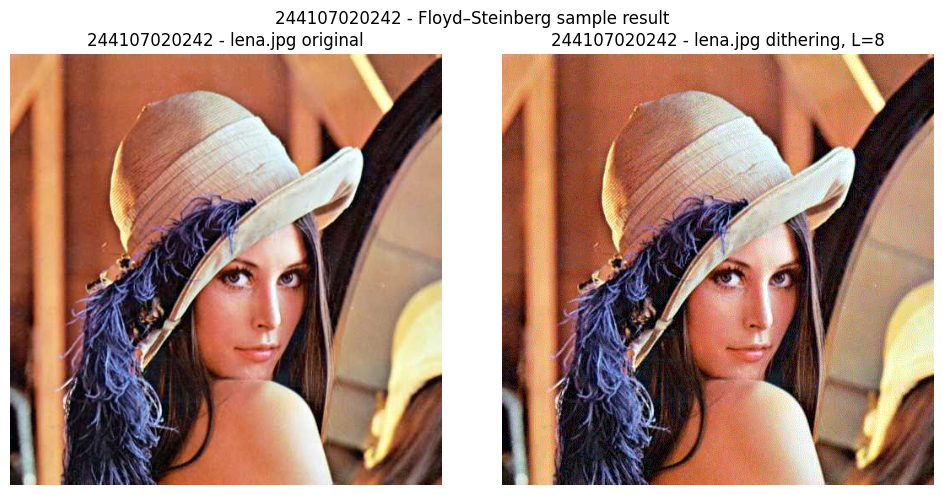

In [62]:
# Stage 1: verify using lena.jpg
lena = read_color(os.path.join(EXAMPLE, 'lena.jpg'))
lena_dithered = floyd_steinberg_color(lena, PARAM['L'])

display_images(
    [
        (lena, 'lena.jpg original'),
        (lena_dithered, 'lena.jpg dithering, L=' + str(PARAM['L']))
    ],
    'Floyd–Steinberg sample result',
    figsize=(10, 5)
)


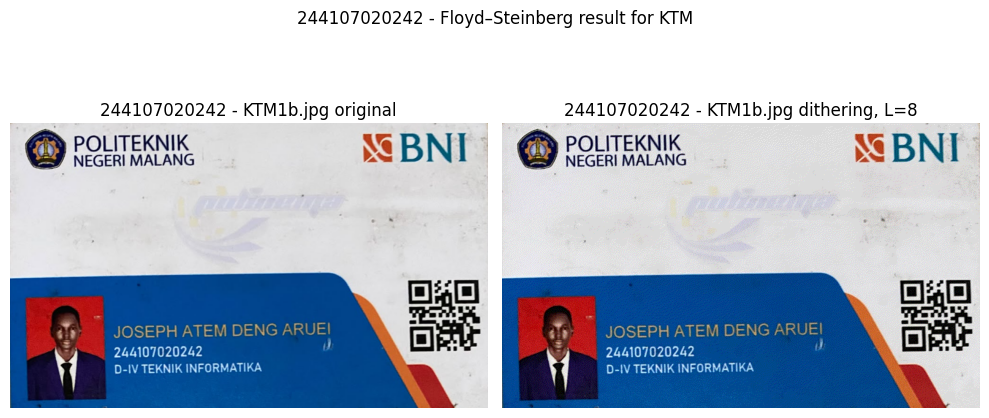

In [63]:
# Stage 2: repeat using KTM1b.jpg
ktm1b = read_color(os.path.join(BASE, 'KTM1b.jpg'))
ktm1b_dithered = floyd_steinberg_color(ktm1b, PARAM['L'])

display_images(
    [
        (ktm1b, 'KTM1b.jpg original'),
        (ktm1b_dithered, 'KTM1b.jpg dithering, L=' + str(PARAM['L']))
    ],
    'Floyd–Steinberg result for KTM',
    figsize=(10, 5)
)

In [64]:
def compare_dithering_sequences(file, image_name):
    gray = read_gray(file)

    # Direct dithering
    direct_dither = floyd_steinberg_channel(gray, PARAM['L'])

    # Equalization followed by dithering
    equalized = cv.equalizeHist(gray)
    equalized_dither = floyd_steinberg_channel(equalized, PARAM['L'])

    display_images(
        [
            (gray, image_name + ' original grayscale'),
            (direct_dither, 'Direct dithering'),
            (equalized, 'Histogram equalization'),
            (equalized_dither, 'Equalization then dithering')
        ],
        'Dithering sequence comparison: ' + image_name,
        figsize=(16, 5)
    )

    return direct_dither, equalized, equalized_dither

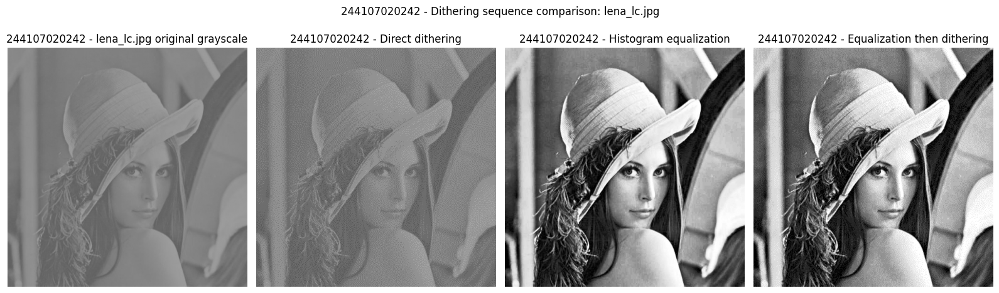

In [65]:

# Stage 1: verify with lena_lc.jpg
lena_lc_results = compare_dithering_sequences(
    os.path.join(EXAMPLE, 'lena_lc.jpg'),
    'lena_lc.jpg'
)

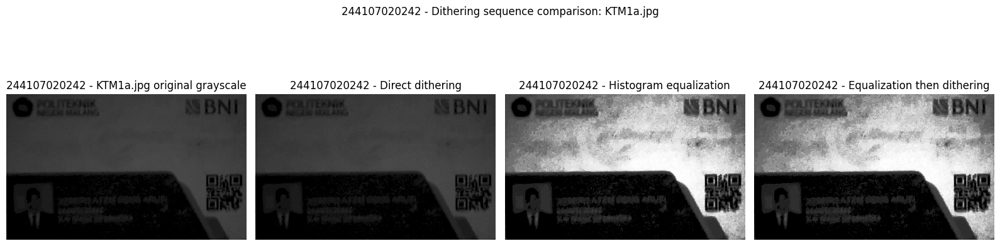

In [66]:
# Stage 2: repeat with KTM1a.jpg
ktm1a_results = compare_dithering_sequences(
    os.path.join(BASE, 'KTM1a.jpg'),
    'KTM1a.jpg'
)